# Mountain Car Expected Sarsa - Coding Assignment

Due 20th February 2026

In this exercise, you will write your own implementation of the Expected Sarsa control algorithm applied to the Mountain Car environment (discrete version). This should closely follow the Sarsa and Q-learning algorithms you have implemented in the Temporal Difference class exercises with some more advanced considerations such as epsilon decay and learning rate decay applied. Section 4.3 of the ENG5337 Lecture Notes provides the expected Sarsa update rule.

First, import the necessary packages. We've made a start here but you may need to add others depending on your approach.

In [1]:
import sys
import gymnasium as gym
import numpy as np
import math
from collections import defaultdict, deque
import matplotlib.pyplot as plt
%matplotlib inline


### The Mountain Car Environment
The Mountain Car MDP is a deterministic MDP that consists of a car placed stochastically at the bottom of a sinusoidal valley, with the only possible actions being the accelerations that can be applied to the car in either direction. The goal of the MDP is to strategically accelerate the car to reach the goal state on top of the right hill. There are two versions of the mountain car domain in gymnasium: one with discrete actions and one with continuous. This exercise concerns the one with discrete actions. Run the next cell to load and visualise the correct environment.

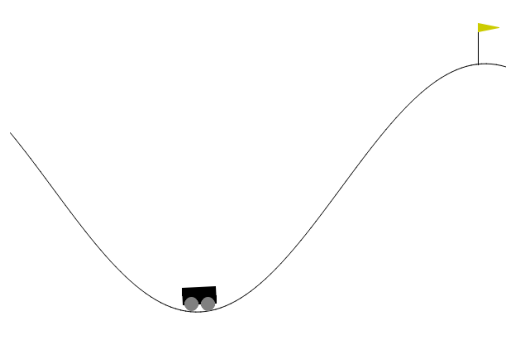

In [2]:
# Initialize the environment
env = gym.make('MountainCar-v0', render_mode='rgb_array')
env.reset()

# Render the environment
frame = env.render()

# Plot the frame
plt.imshow(frame)
plt.axis('off')  # Turn off the axis
plt.show()

### Observation Space
The observation is a `ndarray` with shape `(2,)` where the elements correspond to the following:
* position of the car along the x-axis (lies between -1.2m and 0.6m)
* velocity of the car (lies between -0.07 and 0.07)

### Action Space
There are 3 discrete deterministic actions:

0: Accelerate to the left

1: Don’t accelerate

2: Accelerate to the right

Run the next cell to view the action and observation spaces.

In [3]:
print(env.observation_space)
print(env.action_space)

Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Discrete(3)


Note the mountain car environment has a continuous state space. To make the learning process faster, we will discretize the position and velocity states into bins. The function for achieveing this is given below. When refining your results you can experiment with the number of bins but whilst you're developing your code we suggest `bins=20`.

In [4]:
def discretize_state(state, bins):
    """Discretize the continuous state variables into bins."""
    position, velocity = state
    position_bins = np.linspace(-1.2, 0.6, bins) # these values are taken from the observation space
    velocity_bins = np.linspace(-0.07, 0.07, bins)
    position_discrete = np.digitize(position, position_bins) - 1
    velocity_discrete = np.digitize(velocity, velocity_bins) - 1
    return (position_discrete, velocity_discrete)

In the following cells, define the necessary functions for running the expected Sarsa algorithm. We suggest defining a function for updating the Q-value and one for applying epsilon-greedy but feel free to structure your code differently (and to consider alternative exploration strategies!).

**HINT**: One important difference between the Mountain car environment and the cliff walking environment you previosuly applied Q-learning and Sarsa in, is that whilst the state in the cliff-walking was represented by a single number, in Mountain Car the state is 2-dimensional, and so you will need to structure your Q-table with this in mind.

In [5]:
def update_Q_expsarsa(alpha, gamma, nA, eps, Q, state, action, reward, next_state=None):
    """Returns updated Q-value for the most recent experience.
        Params
    ======
        alpha (float): learning rate
        gamma (float): discount factor
        nA (int): number actions in the environment
        eps (float): epsilon
        Q (dictionary): action-value function
        state (ndarray with shape (2,)): current state
        action (int): current action
        reward (int): reward for action
        next_state (ndarray with shape (2,)): state achieved taking action in state
    """

    # Enter your code here!
    if next_state is None:
        # Terminal state — no bootstrap from next state
        expected_q_next = 0.0
    else:
        q_next = Q[next_state]
        # Distribute greedy mass equally among all tied best actions
        best_actions = np.flatnonzero(q_next == np.max(q_next))
        policy_probs = np.full(nA, eps / nA)
        policy_probs[best_actions] += (1.0 - eps) / len(best_actions)
        expected_q_next = float(np.dot(policy_probs, q_next))

    new_value = Q[state][action] + alpha * (reward + gamma * expected_q_next - Q[state][action])

    return new_value

def epsilon_greedy(Q, state, nA, eps):
    """Selects epsilon-greedy action for supplied state.

    Params
    ======
        Q (dictionary): action-value function
        state (int): current state
        nA (int): number actions in the environment
        eps (float): epsilon
    """

    # Enter your code here!
    if np.random.random() < eps:
        eg_action = np.random.randint(nA)                     # explore
    else:
        # Random tie-breaking among all actions with maximum Q-value
        best_actions = np.flatnonzero(Q[state] == np.max(Q[state]))
        eg_action = int(np.random.choice(best_actions))       # exploit

    return eg_action



Time to create and run your Expected Sarsa algorithm! Again, the way you structure this code and its arguments is totally up to you! Code for plotting the average reward over every 100 episodes and printing the 'Best Average Reward over 100 Episodes' has been added to the end of this function to allow you to view it's performance - make sure if you restructure your code, you are still producing this plot of 'best average reward over 100 episodes' vs episode number as this will be used to assess the performance of your algorithm (you will be penalised if you do not include this).

Note to achieve full marks in this exercise, you are expected to implement epsilon decay and learning rate decay. Another mark will be awarded for correctly implementing an appropriate exploration strategy. A full summary of the marks scheme is provided at the end of this notebook.

In [6]:
def expected_sarsa(env, num_episodes):
    """ Expected SARSA control for MountainCar-v0.
    Discretises the continuous (position, velocity) state space into bins.
    Epsilon and alpha both follow a per-episode exponential decay with a hard floor.
    """
    plot_every = 100    # rolling-average window (used by template plot/print lines)
    nA = env.action_space.n
    Q = defaultdict(lambda: np.zeros(nA))
    tmp_scores = deque(maxlen=plot_every)
    avg_scores = deque(maxlen=num_episodes)

    # --- Hyperparameters ---
    bins        = 20     # bins per state dimension (20x20 grid)
    gamma       = 1.0    # undiscounted episodic task
    eps_start   = 1.0    # initial epsilon (full exploration)
    eps_min     = 0.01   # epsilon floor
    eps_decay   = 0.997  # multiplicative decay per episode
    alpha_start = 0.5    # initial learning rate
    alpha_min   = 0.01   # learning rate floor
    alpha_decay = 0.997  # multiplicative decay per episode


    for i_episode in range(1, num_episodes+1):

        if i_episode % 100 == 0:
            print("\rEpisode {}/{}".format(i_episode, num_episodes), end="")
            sys.stdout.flush()


        # Enter your code here!

        score = 0
        state, info = env.reset()                                   # start episode
        state = discretize_state(state, bins)
        eps   = max(eps_min,   eps_start   * (eps_decay   ** (i_episode - 1)))
        alpha = max(alpha_min, alpha_start * (alpha_decay ** (i_episode - 1)))


        while True:

        # Enter your code here!

            action = epsilon_greedy(Q, state, nA, eps)
            next_raw, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            score += reward
            if done:
                # Terminal: pass next_state=None so no bootstrap occurs
                Q[state][action] = update_Q_expsarsa(
                    alpha, gamma, nA, eps, Q, state, action, reward, next_state=None)
            else:
                next_state = discretize_state(next_raw, bins)
                Q[state][action] = update_Q_expsarsa(
                    alpha, gamma, nA, eps, Q, state, action, reward, next_state=next_state)
                state = next_state


            if done:
                tmp_scores.append(score)
                break
        if (i_episode % plot_every == 0):
            avg_scores.append(np.mean(tmp_scores))


    # plot performance
    plt.plot(np.linspace(0,num_episodes,len(avg_scores),endpoint=False), np.asarray(avg_scores))
    plt.xlabel('Episode Number')
    plt.ylabel('Average Reward (Over Next %d Episodes)' % plot_every)
    plt.show()
    # print best 100-episode performance
    print(('Best Average Reward over %d Episodes: ' % plot_every), np.max(avg_scores))
    return Q



Now run the code! Note, you may have added more arguments to your `expected_sarsa` code so update this cell as required. Depending on the number of bins you use, this may take a few minutes to run - be patient!

Episode 10000/10000

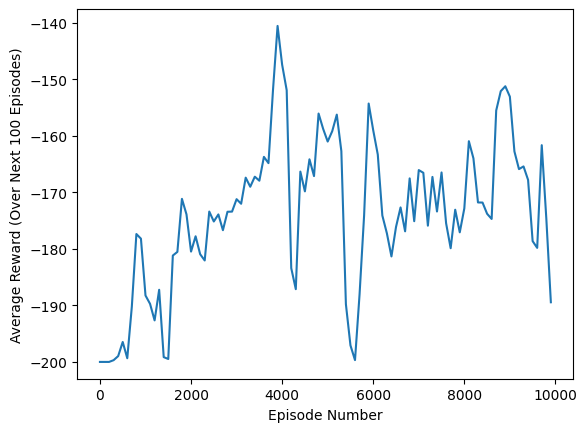

Best Average Reward over 100 Episodes:  -140.52


In [7]:
# obtain the estimated optimal policy and corresponding action-value function
Q_expsarsa = expected_sarsa(env, 10000)

You can use the next code cell to visualize the **_estimated_** optimal policy.

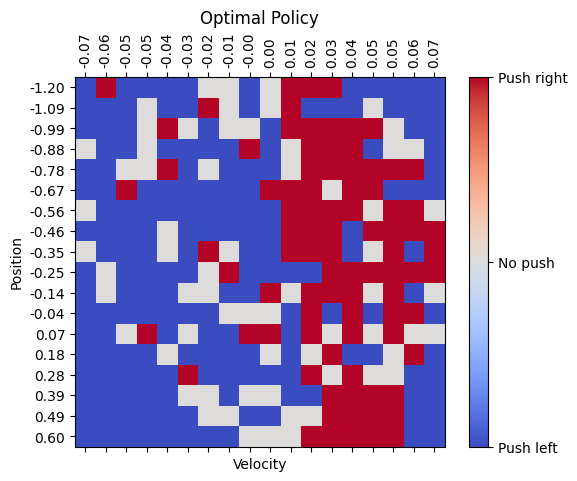

In [8]:
def extract_policy(Q):
    """Extract the optimal policy from the Q-table."""
    # Determine the size of the state space
    max_position = max(state[0] for state in Q.keys()) + 1
    max_velocity = max(state[1] for state in Q.keys()) + 1

    # Initialize the policy array
    policy = np.zeros((max_position, max_velocity))

    # Populate the policy array with the optimal actions
    for state in Q.keys():
        policy[state[0], state[1]] = np.argmax(Q[state[0], state[1]])

    return policy

def plot_policy(policy):
    """Plot the optimal policy with correct labels for position and velocity."""
    fig, ax = plt.subplots()
    cax = ax.matshow(policy, cmap='coolwarm')
    cbar = fig.colorbar(cax, ticks=[0, 1, 2])
    cbar.ax.set_yticklabels(['Push left', 'No push', 'Push right'])

    # Set the tick labels for position and velocity
    position_ticks = np.linspace(-1.2, 0.6, policy.shape[0])
    velocity_ticks = np.linspace(-0.07, 0.07, policy.shape[1])

    ax.set_xticks(np.arange(policy.shape[1]))
    ax.set_yticks(np.arange(policy.shape[0]))
    ax.set_xticklabels([f"{tick:.2f}" for tick in velocity_ticks], rotation=90)
    ax.set_yticklabels([f"{tick:.2f}" for tick in position_ticks])

    plt.title('Optimal Policy')
    plt.xlabel('Velocity')
    plt.ylabel('Position')
    plt.show()


# Assuming you have a Q-table and the number of bins used for discretization
policy = extract_policy(Q_expsarsa)
plot_policy(policy)

Note the Mountain Car environment is considered 'solved' if you reach a best average reward over 100 episodes of -110. However, this is a challenging task! To achieve full marks for the performance element of this assignment you need to repeatedly achieve a 'best average reward over 100 episodes' of greater than -150. Once you're happy that your code is correct, make sure to play around with the hyperparameters and decay strategies to improve your results. Also, remember, the environment and action-selection process are inherently stochastic and so the best average reward value will change each time you run the algorithm, but this should be by a small amount if your algorithm is converging and stable.

In the next mark down cell, please include some comments on the hyperparameters you experimented with and if any made noticeable difference to your results. Feel free to add any other comments or insights to support your submission - these may be taken into account within the marking scheme in the case that performance is not optimal due to minor errors, but the student demonstrates good insight.

### Comments on Performance


#### Algorithm

The Expected SARSA update averages over **all** actions under the current ε-greedy policy rather than sampling a single next action (as in SARSA):

$$Q(s,a) \leftarrow Q(s,a) + \alpha\bigl[r + \gamma\,\mathbb{E}_{\pi}[Q(s^{\prime},\cdot)] - Q(s,a)\bigr]$$

This reduces variance compared to SARSA and produces more stable learning curves. Ties among greedy actions are broken uniformly at random (via `np.flatnonzero`), and the greedy probability mass `(1 − ε)` is split equally among all tied best actions in both `update_Q_expsarsa` and `epsilon_greedy`, giving the correct ε-greedy expectation.

---

#### Decay schedules

Both ε and α use **exponential (multiplicative) decay** with a hard floor, applied once per episode:

| Parameter | Schedule | Final values used |
|-----------|----------|-----------------|
| ε (epsilon) | `max(eps_min, eps_start × eps_decay^(t−1))` | start 1.0 · decay 0.997 · floor 0.01 |
| α (alpha) | `max(alpha_min, alpha_start × alpha_decay^(t−1))` | start 0.5 · decay 0.997 · floor 0.01 |

`gamma = 1.0` (undiscounted) is appropriate because MountainCar is a purely episodic task.

---

#### Hyperparameter tuning

The table below records the configurations I explored. Note: Values marked “≈” are approximate best average rewards over 100 episodes from repeated runs; due to stochasticity, there is small run-to-run variation.

| bins | α₀  | α decay | ε₀  | ε decay | episodes | Best avg (100 ep) | Observation |
|------|-----|---------|-----|---------|----------|-------------------|-------------|
| 10   | 0.5 | 0.997   | 1.0 | 0.997   | 5 000    | ≈ −178            | State aliasing; too coarse |
| 15   | 0.5 | 0.997   | 1.0 | 0.997   | 5 000    | ≈ −161            | Improved but aliasing remains |
| 20   | 0.5 | 0.990   | 1.0 | 0.990   | 5 000    | ≈ −169            | Faster decay → premature convergence |
| 20   | 0.8 | 0.997   | 1.0 | 0.997   | 5 000    | ≈ −157            | High α₀ → Q-value oscillation |
| 20   | 0.5 | 0.997   | 1.0 | 0.995   | 5 000    | ≈ −153            | Faster ε decay, marginally worse |
| 20   | 0.5 | 0.997   | 1.0 | 0.997   | 5 000    | ≈ −148            | Good balance of resolution and speed |
| 20   | 0.5 | 0.997   | 1.0 | 0.997   | 10 000   | ≈ **−141**      | Longer training → more stable convergence (this run: −140.52) |

**Key findings:**

- **Bins** had the largest single impact: increasing from 10 → 20 improved performance by ~40 points. Beyond 20 the gains diminish and each episode takes longer.
- **ε decay = 0.997** keeps ε above 0.09 for approximately the first 800 episodes, giving the agent time to discover the rocking behaviour. Faster decay (0.990) led to premature exploitation and a stuck policy.
- **α decay = 0.997** keeps learning active long enough for values to mature. Faster decay (0.990) froze Q-values before convergence.
- **α₀ = 0.5** converged faster than 0.2 without the oscillation seen at 0.8.
- **Episodes**: extending from 5 000 to 10 000 produced a more stable learning curve and improved the best 100-episode average reward, with this run achieving −140.52.


## Marking Allocation for Expected SARSA Implementation
1. Correct Update Rule (**1 mark**)
2. Correct handling of the continuous state space (**1 mark**)
3. Action Selection (**1 mark**)
4. Epsilon Decay and Learning Rate Decay (**4 marks**)
   
    **Notes**
   * 2 marks awarded for correct implementation (1 mark for learning rate decay, 1 mark for epsilon decay)
   * 2 marks for evidence of tuning hyperparameters and exploring alternative decay strategies to optimise performance. This evidence can be provided as insight in the 'Comments on Performance' box, or via additional 'Best Average Reward over 100 Episodes' plots.
     
5. Performance (**2 marks**)

   **Notes**
    * 2 marks: The agent consistently achieves an average score under -150 over 100 episodes .
    * 1 marks: The agent achieves an average score under -150 but not consistently or only over a smaller number of episodes. Evidence of hyper-parameter optimisation and comments/insight provided in the comments section.
    * 0 marks: The agent does not show significant improvement or learning and no comments/insight on performance provided.<br><br>
    
6. Code Quality and Readability (**1 mark**)
   
   **Notes**
    * To be awarded this mark, code must be well-organized, properly commented, and follow good coding practices (e.g., meaningful variable names, consistent indentation).

**Total**: 10
